Checkerboard pattern saved to checkerboard.h


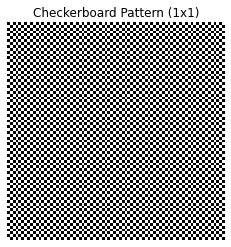

In [8]:
import numpy as np
import matplotlib.pyplot as plt

def generate_checkerboard(size=512, block_size=1):
    # Initialize the checkerboard array
    checkerboard = np.zeros((size, size), dtype=np.uint32)

    # Generate the checkerboard pattern
    for i in range(size):
        for j in range(size):
            block_i, block_j = i // block_size, j // block_size
            if (block_i + block_j) % 2 == 0:
                checkerboard[i, j] = 0x00000000
            else:
                checkerboard[i, j] = 0x0000001F

    return checkerboard

def save_as_c_array(checkerboard, filename='checkerboard.h'):
    # Flatten the array and format it as a C-style array
    c_array = "const uint32_t checkerboard[] = {\n"
    flat_checkerboard = checkerboard.flatten()

    for i in range(0, len(flat_checkerboard), 16):
        row = flat_checkerboard[i:i+16]
        c_array += "    " + ", ".join([f"0x{v:08X}" for v in row]) + ",\n"

    c_array += "};\n"

    # Save the C array to a file
    with open(filename, 'w') as file:
        file.write(c_array)

    print(f"Checkerboard pattern saved to {filename}")

def display_checkerboard(checkerboard):
    # Display the checkerboard as an image
    plt.imshow(checkerboard, cmap='gray', interpolation='nearest')
    plt.title('Checkerboard Pattern (1x1)')
    plt.axis('off')
    plt.show()

# Generate the checkerboard with 1x1 squares
checkerboard = generate_checkerboard(block_size=1)

# Save the checkerboard as a C array
save_as_c_array(checkerboard)

# Display the checkerboard
display_checkerboard(checkerboard)